In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import torch as pt
import os
import PcmPy as pcm
from Functional_Fusion.dataset import DataSetMDTB
import Functional_Fusion.atlas_map as am
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.util as ut
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.evaluation as ev
from OptimalBattery.util import eigenval_crit,build_combinations, combination_vectors
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import nitools as nt
from IndividualParcellation.global_config import *



In [2]:
# Check if CUDA is available
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Define ROIs to be used for the analysis
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
if not os.path.exists(base_dir):
    base_dir = 'Y:/data/FunctionalFusion'

space = 'SUIT3'
atlas, _ = am.get_atlas(space)

In [4]:
# Load the data
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')

#make nans zero
data_mdtb_s1[np.isnan(data_mdtb_s1)] = 0

# get the G matrix

In [5]:
n_conds = len(np.unique(info_mdtb_1['cond_name']))
n_runs = len(np.unique(info_mdtb_1['run']))
cond_names = np.unique(info_mdtb_1['cond_name'])

In [6]:
cond_vec = np.tile(np.arange(1, n_conds + 1), n_runs)
part_vec = np.repeat(np.arange(1, n_runs + 1), n_conds)

Gs_list = []
for i in range(data_mdtb_s1.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1[i], cond_vec, part_vec)
    Gs_list.append(Gs)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)


<Axes: >

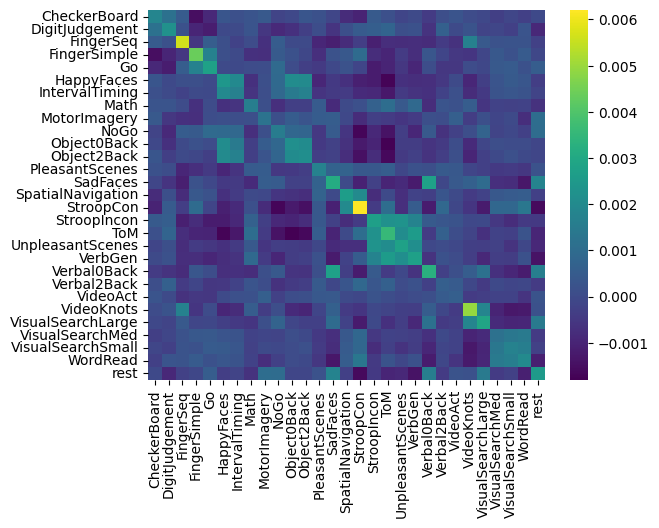

In [7]:
sns.heatmap(G_individuals_averaged, cmap='viridis',xticklabels=cond_names, yticklabels=cond_names)

# Build combinations

In [24]:
D = build_combinations(G_individuals_averaged, strategy='random',n_iter=100,n_tasks=8)

In [25]:
np.unique(D.n_unique)

array([5, 6, 7, 8], dtype=int64)

# Perform DCBC on combinations

In [26]:
# Constants for the full model
directory = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
if not os.path.exists(directory):
    directory = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/'
k= 16

model_path = f'{directory}/language-localizer_mdtb-s1_fusion_k{k}_{space}.pkl'
with open(model_path, 'rb') as file:
    model = pickle.load(file)

sym_type = 'unsym'
ar_model = model.arrange
ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())

P = atlas.P
K = ar_model.K

dist = compute_dist(atlas.world.T, resolution=1)


# Load the evaluation data
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s2,_  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondRun')

#make nans zero
data_mdtb_s2[np.isnan(data_mdtb_s2)] = 0



c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than pt.tensor(sourceTensor).
  return func(*args, **kwargs)


In [27]:
def perform_dcbc_combination(data_train,cond_vec,part_vec,data_eval):
    
    x_matrix = ut.indicator(cond_vec)
    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([data_train])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation
    
    if isinstance(data_eval, np.ndarray):
        data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
    if isinstance(U_data, np.ndarray):
        U_data = pt.tensor(U_data, dtype=pt.get_default_dtype())
    
    Pindiv = pt.argmax(U_data, dim=1) + 1
    dcbc_indiv = calc_test_dcbc(Pindiv, data_eval, dist,progress_updates= False)
    return dcbc_indiv.mean()


In [28]:
counter = 0
def evaluate_combination(combination):
    global counter
    counter += 1
    print(f"Combination {counter}")
    data_train, cond_v_train, part_v_train = combination_vectors(data_mdtb_s1, info_mdtb_1, combination, n_repeats=2)
    dcbc_value = perform_dcbc_combination(data_train, cond_v_train, part_v_train, data_mdtb_s2)
    dcbc_value = dcbc_value.item()
    
    return dcbc_value

In [29]:
unique_combinations_df = D[D['offset'] == D['offset'].min()].copy()
unique_combinations_df['dcbc'] = unique_combinations_df['combination'].apply(evaluate_combination)


Combination 1
Combination 2
Combination 3
Combination 4
Combination 5
Combination 6
Combination 7
Combination 8
Combination 9
Combination 10
Combination 11
Combination 12
Combination 13
Combination 14
Combination 15
Combination 16
Combination 17
Combination 18
Combination 19
Combination 20
Combination 21


C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 29
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


Combination 22


C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 180
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


Combination 23


...

Combination 91
Combination 92


C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 35
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


Combination 93
Combination 94


C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 60
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


Combination 95
Combination 96
Combination 97
Combination 98
Combination 99
Combination 100


In [30]:
D['combination'] = D['combination'].apply(tuple)
unique_combinations_df['combination'] = unique_combinations_df['combination'].apply(tuple)

# Now perform the merge operation using the tuple values
D = D.merge(
    unique_combinations_df[['combination', 'dcbc']], 
    on='combination', 
    how='left'
)

In [16]:
# save the results tsv
# D.to_csv(f'dcbc_combinations_{space}_full_cerebellum.tsv', sep='\t', index=False)

# Analyze the results

In [31]:
# subset only the 0.001 offset
A = D[D['offset'] == 0.001].copy()

<Axes: xlabel='has_repeats', ylabel='min_est'>

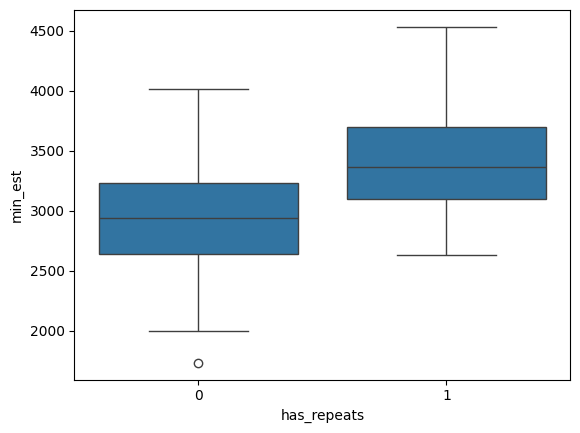

In [32]:
sns.boxplot(x='has_repeats', y='min_est', data=A)


In [33]:
len(D)

300

<Axes: xlabel='has_repeats', ylabel='log_det'>

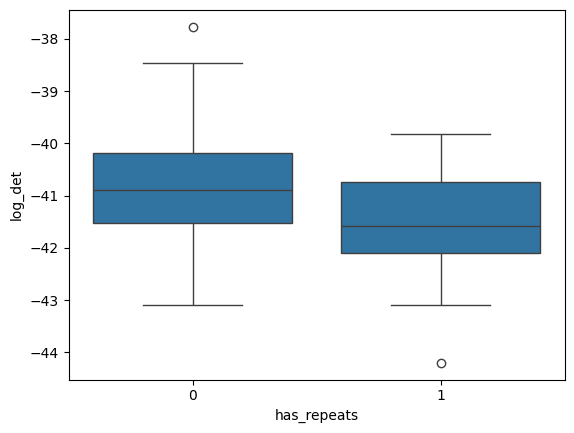

In [34]:
sns.boxplot(x='has_repeats', y='log_det', data=A)


<Axes: xlabel='has_repeats', ylabel='max_var'>

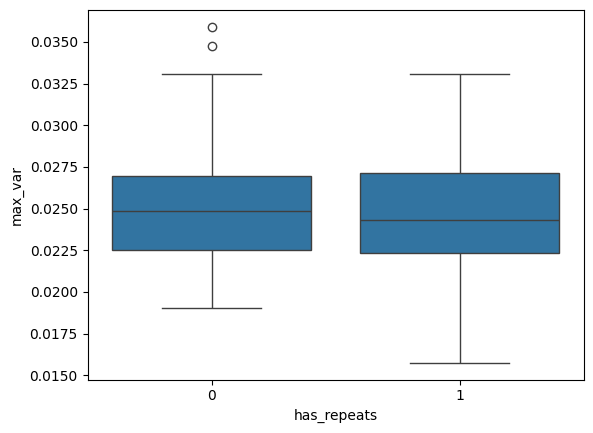

In [35]:
sns.boxplot(x='has_repeats', y='max_var', data=A)


In [36]:
# show many combinations are repeated
n_repeated = len(A[A['has_repeats'] == True])
n_unique = len(A[A['has_repeats'] == False])

n_repeated, n_unique


(61, 39)

<Axes: xlabel='dcbc', ylabel='Count'>

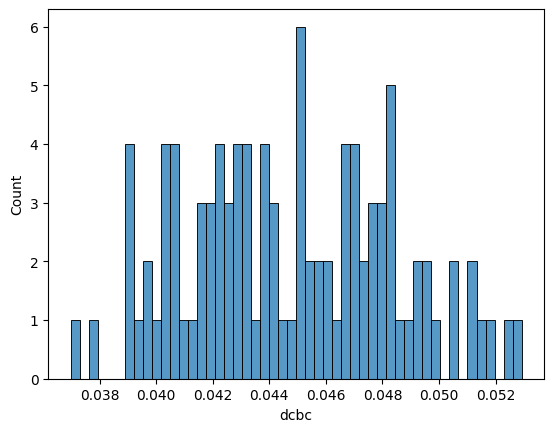

In [37]:
# plot the distribution of the DCBC values
sns.histplot(A['dcbc'], bins=50)

<Axes: xlabel='min_est', ylabel='max_var'>

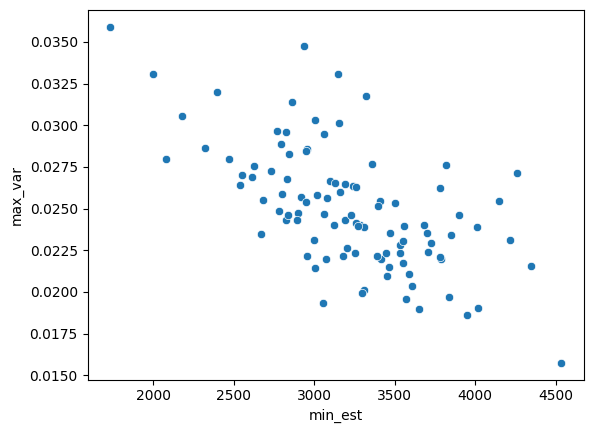

In [59]:
sns.scatterplot(x='min_est', y='max_var', data=A)

In [1]:
# get the two variables for Dcbc and log_det
log_det_list = A['log_det_4'].values
dcbc_list = A['dcbc'].values

from scipy.stats import pearsonr
r_value, p_value = pearsonr(log_det_list, dcbc_list)

print(f"Correlation between log_det and DCBC: {r_value}, p-value: {p_value}")

NameError: name 'A' is not defined

In [40]:
# get the two variables for DCBC and min_est
min_est_list = A['min_est'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(min_est_list, dcbc_list)

print(f"Correlation between min_est and DCBC: {r_value}, p-value: {p_value}")


Correlation between min_est and DCBC: -0.41585997438058886, p-value: 1.685903764593401e-05


In [41]:
# get the two variables for DCBC and max_var
max_var_list = A['max_var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: 0.4364672441394139, p-value: 5.6357883579249e-06


In [51]:
# get the two variables for DCBC and max_var
max_var_list = A['effective_rank'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: 0.45627158431380754, p-value: 1.8339411043549713e-06


<Axes: xlabel='n_unique', ylabel='dcbc'>

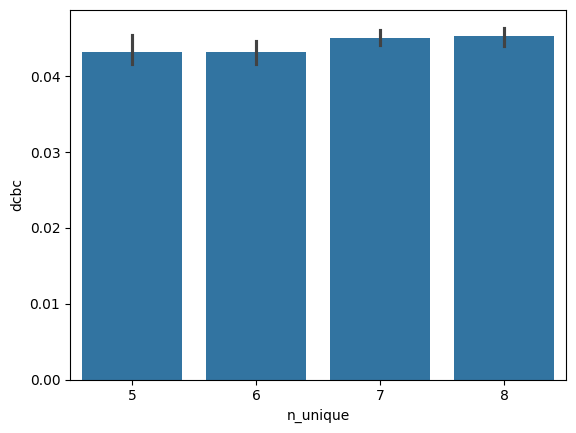

In [54]:
# plot number of unique tasks vs DCBC
sns.barplot(x='n_unique', y='dcbc', data=A)
